# 06 — Recommendation Ranking (Fase 3F) + Asistente Clínico (3G)

Top-5 acciones por paciente, ordenadas por **impacto esperado** (impacto base × relevancia según estado). Cada acción lleva su razón.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


In [2]:
recs = load(DS/'recommendations.json')
from collections import Counter
c = Counter(a['label'] for r in recs for a in r['recommendations'])
pd.DataFrame(c.most_common(), columns=['acción','frecuencia'])

,acción,frecuencia
0,Programar consulta,400
1,Derivar a especialista,226
2,Evaluar factores de riesgo modificables,225
3,Contacto preventivo,218
4,Revisar/ajustar tratamiento,217
5,Actualizar glucosa,214
6,Actualizar signos vitales (PA/peso),176
7,Reforzar adherencia al tratamiento,164
8,Educación en hábitos (dieta/actividad),6


## Ejemplo: Top-5 del paciente más prioritario

In [3]:
ex = max(recs, key=lambda r: r['priority']['score'])
for a in ex['recommendations']:
    print(f"  {a['rank']}. {a['label']}  — {a['reason']}")

  1. Derivar a especialista  — Riesgo 1.00 + 3 comorbilidades
  2. Revisar/ajustar tratamiento  — [R04] Glucosa en rango muy alto: revisar tratamiento y reconfirmar medición
  3. Programar consulta  — Prioridad clínica = 87/100
  4. Reforzar adherencia al tratamiento  — Adherencia 38%
  5. Contacto preventivo  — Riesgo muy alto (1.00)


## Módulo 'Asistente Clínico' (Fase 3G)
Mockup del panel dentro del expediente (`/pacientes/[id]/evolucion`). Ver `ASISTENTE_CLINICO_SPEC.md` para la integración.

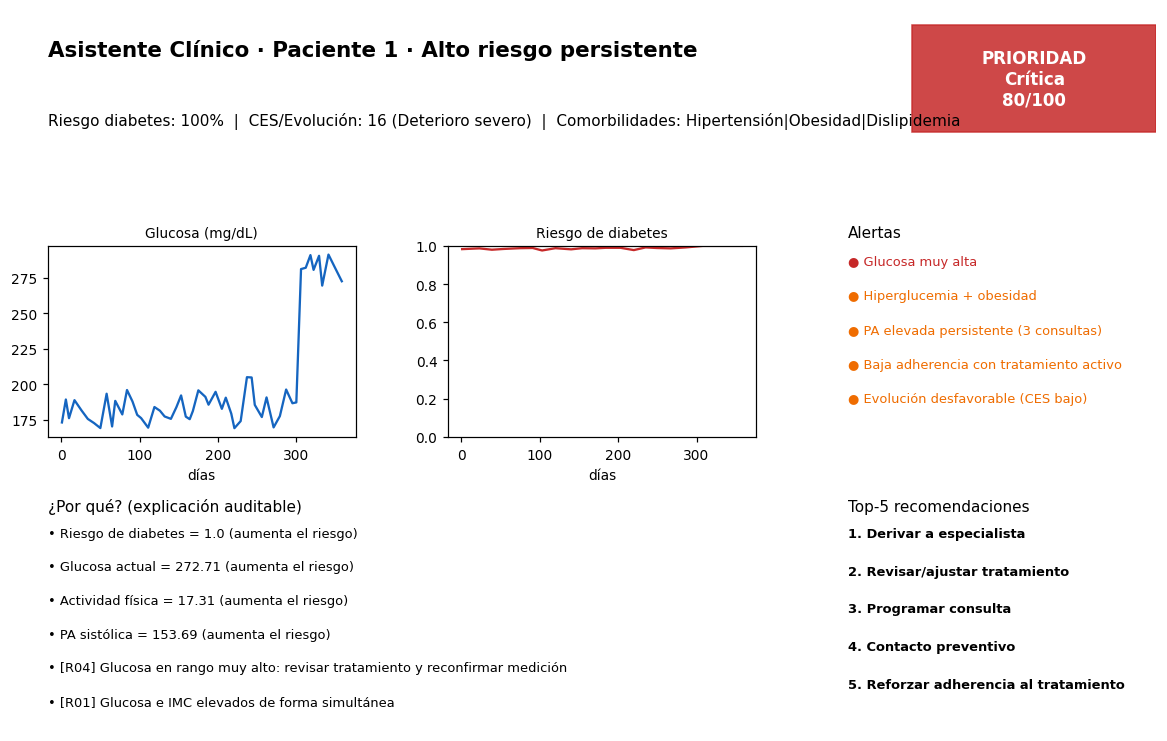

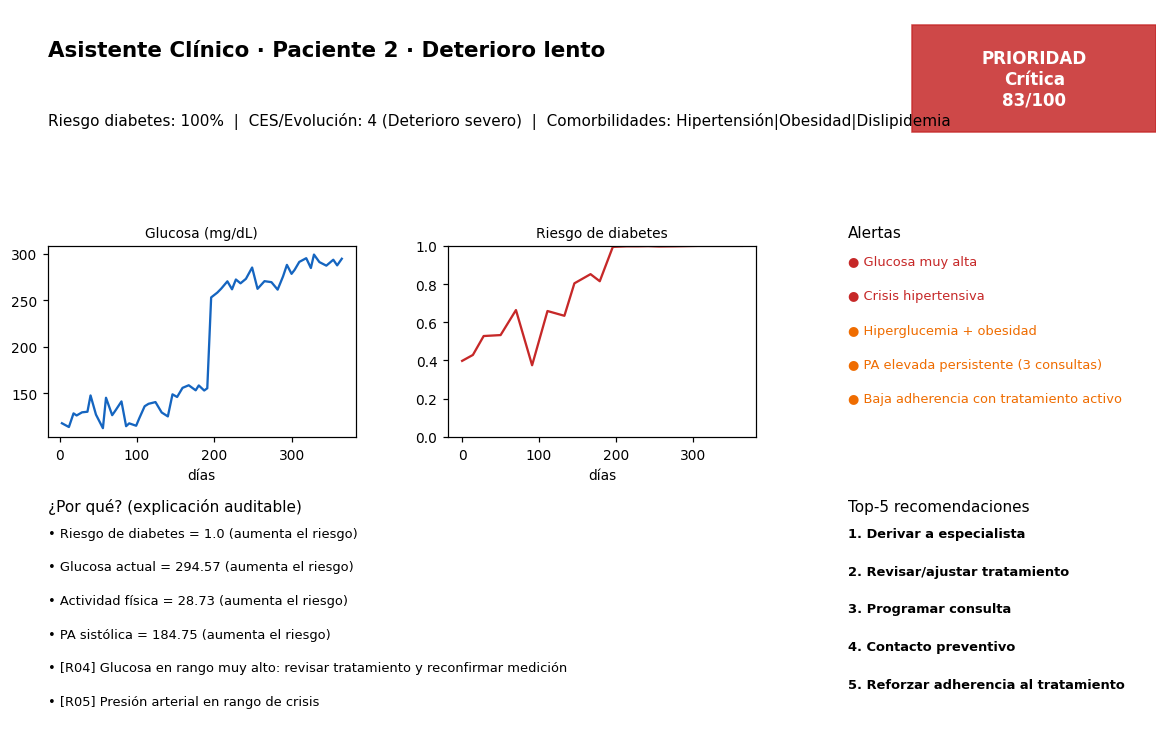

In [4]:
for p in sorted(DASH.glob('asistente_*.png'))[:2]: show(p)

### Conclusión 3F/3G
Cada paciente recibe acciones concretas y priorizadas, presentadas en un panel explicable listo para el expediente.